In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
import statistics

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from tqdm.notebook import tqdm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from tqdm.notebook import tqdm




In [2]:
df = pd.read_csv('train_pattern.csv') 

In [3]:
df

,rating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,titleType,awardNominationsExcludeWins,canHaveEpisodes,isAdult,numRegions,userReviewsTotal,countryOfOrigin,genres
0,"(7, 8]",2020,80,1,15718,347,2,47,4,tvSeries,1,True,False,32,452,['Other Countries'],"['Comedy', 'Drama', 'Romance']"
1,"(8, 9]",1995,34,0,14,1,0,0,0,video,0,False,False,1,1,['US'],"['Documentary', 'Short']"
2,"(7, 8]",1995,45,0,96,5,0,110,0,tvEpisode,0,False,False,1,0,['US'],"['Drama', 'Romance']"
3,"(7, 8]",1996,12,2,12,1,0,2,0,short,0,False,False,1,0,['Other Countries'],"['Short', 'Animation-Family']"
4,"(8, 9]",2017,44,0,33,1,0,5,0,tvMovie,0,False,False,1,0,['US'],['Action-Adventure']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11574,"(7, 8]",2019,42,0,34,131,0,61,0,tvEpisode,0,False,False,1,0,['CA'],"['Drama', 'Crime-Mystery']"
11575,"(5, 6]",1954,7,0,34,18,0,15,0,short,0,False,False,1,1,['US'],"['Short', 'Animation-Family']"
11576,"(6, 7]",1965,110,0,10,5,0,17,0,movie,0,False,False,3,0,['Other Countries'],"['Drama', 'Romance']"
11577,"(7, 8]",1968,73,0,30,1,0,42,1,tvEpisode,0,False,False,1,1,['US'],"['Action-Adventure', 'Drama', 'Crime-Mystery']"


In [4]:
df.genres.value_counts()

genres
['Drama']                                        1228
['Comedy']                                        887
['Documentary']                                   637
['Drama', 'Crime-Mystery']                        626
['Other genre']                                   350
                                                 ... 
['Comedy', 'Other genre', 'Animation-Family']       1
['Documentary', 'Other genre', 'Reality-TV']        1
['Documentary', 'Drama', 'Crime-Mystery']           1
['Documentary', 'Comedy', 'Reality-TV']             1
['Documentary', 'Drama', 'News-Sports']             1
Name: count, Length: 345, dtype: int64

In [5]:
df.dtypes

rating                         object
startYear                       int64
runtimeMinutes                  int64
awardWins                       int64
numVotes                        int64
totalImages                     int64
totalVideos                     int64
totalCredits                    int64
criticReviewsTotal              int64
titleType                      object
awardNominationsExcludeWins     int64
canHaveEpisodes                  bool
isAdult                          bool
numRegions                      int64
userReviewsTotal                int64
countryOfOrigin                object
genres                         object
dtype: object

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
startYear,11579.0,1990.808705,25.933088,1891.0,1975.0,1996.0,2012.0,2024.0
runtimeMinutes,11579.0,61.222644,52.110187,0.0,25.0,58.0,90.0,3000.0
awardWins,11579.0,0.467657,2.983785,0.0,0.0,0.0,0.0,145.0
numVotes,11579.0,1828.590465,22200.210913,5.0,17.0,46.0,191.0,966565.0
totalImages,11579.0,12.449521,72.696821,0.0,1.0,2.0,7.0,3504.0
totalVideos,11579.0,0.315658,3.586833,0.0,0.0,0.0,0.0,258.0
totalCredits,11579.0,65.480784,193.378246,0.0,18.0,37.0,69.0,15742.0
criticReviewsTotal,11579.0,3.375248,17.024990,0.0,0.0,0.0,1.0,533.0
awardNominationsExcludeWins,11579.0,0.648243,4.485195,0.0,0.0,0.0,0.0,197.0
numRegions,11579.0,3.895760,6.379618,1.0,1.0,1.0,4.0,69.0


In [7]:
# One-hot encode boolean and categorical fields
df['isAdult'] = df['isAdult'].replace({True: 'adult', False: 'not_adult'})
df['canHaveEpisodes'] = df['canHaveEpisodes'].replace({True: 'episodic', False: 'non_episodic'})

In [8]:
# Manual discretization into 4 bins for meaningful interpretation

# Discretizing 'rating' into categories
df['rating'] = df['rating'].apply(lambda x: 
    'very_low_rating' if x in ['(0, 1]', '(1, 2]', '(2, 3]'] else
    ('low_rating' if x in ['(3, 4]','(4, 5]'] else
    ('medium_rating' if x in ['(5, 6]','(6, 7]'] else
    ('high_rating' if x in ['(7, 8]', '(8, 9]', '(9, 10]'] else 'unknown'))))

# Discretizing 'startYear' into historical categories
df['startYear'] = pd.cut(df['startYear'], bins=[1878, 1919, 1949, 1999, df['startYear'].max()], 
                   labels=['early_cinema_era', 'classical_cinema_era', 'modern_cinema_era', 'contemporary_cinema_era'], include_lowest=True)

# Discretizing 'runtimeMinutes'
df['runtimeMinutes'] = pd.cut(df['runtimeMinutes'], bins=[0, 40, 60, 120, df['runtimeMinutes'].max()], 
                   labels=['short_runtime', 'medium_runtime', 'long_runtime', 'very_long_runtime', ], include_lowest=True)

# Discretizing 'awardWins'
df['awardWins'] = pd.cut(df['awardWins'], bins=[0, 1, 3, 10, df['awardWins'].max()], 
                   labels=['no_awards', 'few_awards', 'some_awards', 'many_awards'], include_lowest=True)

# Discretizing 'numVotes'
df['numVotes'] = pd.cut(df['numVotes'], bins=[0, 1000, 10000, 100000,  df['numVotes'].max()], 
                   labels=['low_votes', 'moderate_votes', 'high_votes', 'very_high_votes'], include_lowest=True)

# Discretizing 'totalImages'
df['totalImages'] = pd.cut(df['totalImages'], bins=[0, 10, 50, 200, df['totalImages'].max()], 
                     labels=['very_low_images', 'low_images', 'medium_images', 'high_images'], include_lowest=True)

# Discretizing 'totalVideos'
df['totalVideos'] = pd.cut(df['totalVideos'], bins=[-1, 0, 5, 15, df['totalVideos'].max()], 
                     labels=['no_videos', 'low_videos', 'moderate_videos', 'high_videos'], include_lowest=True)

# Discretizing 'totalCredits'
df['totalCredits'] = pd.cut(df['totalCredits'], bins=[0, 50, 500, 2000, df['totalCredits'].max()], 
                      labels=['small_scale_credits', 'medium_scale_credits', 'large_scale_credits', 'massive_scale_credits'], include_lowest=True)

# Discretizing 'criticReviewsTotal'
df['criticReviewsTotal'] = pd.cut(df['criticReviewsTotal'], bins=[0, 20, 50, 100, df['criticReviewsTotal'].max()], 
                             labels=['low_criticReviews', 'moderate_criticReviews', 'high_criticReviews', 'very_high_criticReviews'], include_lowest=True)

# Discretizing 'awardNominationsExcludeWins'
df['awardNominationsExcludeWins'] = pd.cut(df['awardNominationsExcludeWins'], bins=[0, 1, 3, 10, df['awardNominationsExcludeWins'].max()],
                                      labels=['no_nominations', 'few_nominations', 'some_nominations', 'many_nominations'], include_lowest=True)

# # Discretizing 'numRegions'
df['numRegions'] = pd.cut(df['numRegions'], bins=[0, 1, 5, 10, df['numRegions'].max()], 
                    labels=['local', 'regional', 'international', 'global'], include_lowest=True)

# Discretizing 'userReviewsTotal'
df['userReviewsTotal'] = pd.cut(df['userReviewsTotal'], bins=[0, 50, 200, 500, df['userReviewsTotal'].max()], 
                           labels=['low_userReviews', 'moderate_userReviews', 'high_userReviews', 'very_high_userReviews'], include_lowest=True)


In [9]:
df

,rating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,titleType,awardNominationsExcludeWins,canHaveEpisodes,isAdult,numRegions,userReviewsTotal,countryOfOrigin,genres
0,high_rating,contemporary_cinema_era,long_runtime,no_awards,high_votes,high_images,low_videos,small_scale_credits,low_criticReviews,tvSeries,no_nominations,episodic,not_adult,global,high_userReviews,['Other Countries'],"['Comedy', 'Drama', 'Romance']"
1,high_rating,modern_cinema_era,short_runtime,no_awards,low_votes,very_low_images,no_videos,small_scale_credits,low_criticReviews,video,no_nominations,non_episodic,not_adult,local,low_userReviews,['US'],"['Documentary', 'Short']"
2,high_rating,modern_cinema_era,medium_runtime,no_awards,low_votes,very_low_images,no_videos,medium_scale_credits,low_criticReviews,tvEpisode,no_nominations,non_episodic,not_adult,local,low_userReviews,['US'],"['Drama', 'Romance']"
3,high_rating,modern_cinema_era,short_runtime,few_awards,low_votes,very_low_images,no_videos,small_scale_credits,low_criticReviews,short,no_nominations,non_episodic,not_adult,local,low_userReviews,['Other Countries'],"['Short', 'Animation-Family']"
4,high_rating,contemporary_cinema_era,medium_runtime,no_awards,low_votes,very_low_images,no_videos,small_scale_credits,low_criticReviews,tvMovie,no_nominations,non_episodic,not_adult,local,low_userReviews,['US'],['Action-Adventure']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11574,high_rating,contemporary_cinema_era,medium_runtime,no_awards,low_votes,medium_images,no_videos,medium_scale_credits,low_criticReviews,tvEpisode,no_nominations,non_episodic,not_adult,local,low_userReviews,['CA'],"['Drama', 'Crime-Mystery']"
11575,medium_rating,modern_cinema_era,short_runtime,no_awards,low_votes,low_images,no_videos,small_scale_credits,low_criticReviews,short,no_nominations,non_episodic,not_adult,local,low_userReviews,['US'],"['Short', 'Animation-Family']"
11576,medium_rating,modern_cinema_era,long_runtime,no_awards,low_votes,very_low_images,no_videos,small_scale_credits,low_criticReviews,movie,no_nominations,non_episodic,not_adult,regional,low_userReviews,['Other Countries'],"['Drama', 'Romance']"
11577,high_rating,modern_cinema_era,long_runtime,no_awards,low_votes,very_low_images,no_videos,small_scale_credits,low_criticReviews,tvEpisode,no_nominations,non_episodic,not_adult,local,low_userReviews,['US'],"['Action-Adventure', 'Drama', 'Crime-Mystery']"


In [10]:
X = df.values.tolist()

In [11]:
X[0]

['high_rating',
 'contemporary_cinema_era',
 'long_runtime',
 'no_awards',
 'high_votes',
 'high_images',
 'low_videos',
 'small_scale_credits',
 'low_criticReviews',
 'tvSeries',
 'no_nominations',
 'episodic',
 'not_adult',
 'global',
 'high_userReviews',
 "['Other Countries']",
 "['Comedy', 'Drama', 'Romance']"]

## Pattern mining preprocessing

In [12]:
from fim import apriori

In [13]:
help(apriori)

Help on built-in function apriori in module fim:

apriori(...)
    apriori (tracts, target='s', supp=10, zmin=1, zmax=None, report='a',
             eval='x', agg='x', thresh=10, prune=None, algo='b', mode='',
             border=None)
    Find frequent item sets with the Apriori algorithm.
    tracts  transaction database to mine (mandatory)
            The database must be an iterable of transactions;
            each transaction must be an iterable of items;
            each item must be a hashable object.
            If the database is a dictionary, the transactions are
            the keys, the values their (integer) multiplicities.
    target  type of frequent item sets to find     (default: s)
            s/a   sets/all   all     frequent item sets
            c     closed     closed  frequent item sets
            m     maximal    maximal frequent item sets
            g     gens       generators
            r     rules      association rules
    supp    minimum support of an i

In [14]:
# Set max column width to display full content
pd.set_option('display.max_colwidth', None)

In [15]:
supp = 20 # 20%
zmin = 5  # minimum number of items per item set

itemsets = apriori(X, target="s", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"]).sort_values(by="support", axis=0, ascending=True)

,frequent_itemset,support
1279,"(short_runtime, local, small_scale_credits, no_nominations, not_adult, low_userReviews)",20.001727
1278,"(short_runtime, local, small_scale_credits, no_nominations, not_adult, low_criticReviews)",20.001727
1277,"(short_runtime, local, small_scale_credits, no_nominations, not_adult, low_criticReviews, low_userReviews)",20.001727
86,"(regional, low_votes, non_episodic, no_awards, low_userReviews, not_adult)",20.001727
4400,"(['US'], small_scale_credits, no_videos, no_nominations, non_episodic, low_criticReviews, not_adult, low_userReviews)",20.001727
...,...,...
10855,"(no_videos, low_votes, low_criticReviews, low_userReviews, not_adult)",82.468262
10893,"(low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",83.634165
10889,"(low_votes, no_nominations, no_awards, low_criticReviews, low_userReviews)",83.755074
10899,"(low_votes, no_awards, low_criticReviews, low_userReviews, not_adult)",83.996891


In [16]:
supp = 15 # 20%
zmin = 5  # minimum number of items per item set

itemsets = apriori(X, target="s", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"]).sort_values(by="support", axis=0, ascending=True)

,frequent_itemset,support
8528,"(long_runtime, modern_cinema_era, very_low_images, low_votes, no_nominations, no_awards, low_criticReviews)",15.001295
6998,"(movie, medium_rating, very_low_images, low_criticReviews, low_userReviews, not_adult)",15.001295
12017,"(high_rating, contemporary_cinema_era, local, non_episodic, low_userReviews)",15.001295
163,"(medium_runtime, very_low_images, no_videos, low_votes, not_adult, low_criticReviews)",15.001295
164,"(medium_runtime, very_low_images, no_videos, low_votes, not_adult)",15.001295
...,...,...
20978,"(no_videos, low_votes, low_criticReviews, low_userReviews, not_adult)",82.468262
21016,"(low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",83.634165
21012,"(low_votes, no_nominations, no_awards, low_criticReviews, low_userReviews)",83.755074
21022,"(low_votes, no_awards, low_criticReviews, low_userReviews, not_adult)",83.996891


In [17]:

# supp = 2  # 2%
supp = 10 # 20%
zmin = 5  # minimum number of items per item set

itemsets = apriori(X, target="s", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"]).sort_values(by="support", axis=0, ascending=True)

,frequent_itemset,support
22444,"(short_runtime, contemporary_cinema_era, small_scale_credits, no_videos, low_votes, non_episodic)",10.000864
11766,"(tvEpisode, high_rating, modern_cinema_era, no_videos, low_votes, no_nominations, low_userReviews, not_adult)",10.000864
11767,"(tvEpisode, high_rating, modern_cinema_era, no_videos, low_votes, no_nominations, low_userReviews)",10.000864
11768,"(tvEpisode, high_rating, modern_cinema_era, no_videos, low_votes, no_nominations, not_adult)",10.000864
11769,"(tvEpisode, high_rating, modern_cinema_era, no_videos, low_votes, no_nominations)",10.000864
...,...,...
52820,"(no_videos, low_votes, low_criticReviews, low_userReviews, not_adult)",82.468262
52858,"(low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",83.634165
52854,"(low_votes, no_nominations, no_awards, low_criticReviews, low_userReviews)",83.755074
52864,"(low_votes, no_awards, low_criticReviews, low_userReviews, not_adult)",83.996891


In [18]:
# supp = 2  # 2%
supp = 10  # 20%
zmin = 5  # minimum number of items per item set

itemsets = apriori(X, target="c", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["closed_itemset", "support"]).sort_values(by="support", axis=0, ascending=True)

,closed_itemset,support
2500,"(regional, medium_rating, small_scale_credits, low_votes, no_awards, low_criticReviews, low_userReviews)",10.000864
16512,"(high_rating, contemporary_cinema_era, small_scale_credits, no_videos, no_awards, low_criticReviews, low_userReviews, not_adult)",10.000864
16472,"(high_rating, contemporary_cinema_era, small_scale_credits, very_low_images, no_nominations, no_awards, low_userReviews)",10.000864
2161,"(regional, long_runtime, very_low_images, no_videos, low_votes, no_awards, low_criticReviews, low_userReviews, not_adult)",10.000864
6260,"(short_runtime, ['US'], local, small_scale_credits, non_episodic, no_awards, low_criticReviews, low_userReviews, not_adult)",10.000864
...,...,...
22595,"(no_videos, low_votes, low_criticReviews, low_userReviews, not_adult)",82.468262
22633,"(low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",83.634165
22629,"(low_votes, no_nominations, no_awards, low_criticReviews, low_userReviews)",83.755074
22639,"(low_votes, no_awards, low_criticReviews, low_userReviews, not_adult)",83.996891


In [19]:
itemsets = apriori(X, target="m", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["maximal_itemset", "support"])

,maximal_itemset,support
0,"(['Drama'], low_votes, low_criticReviews, low_userReviews, not_adult)",10.069954
1,"(low_images, no_nominations, no_awards, low_userReviews, not_adult)",10.173590
2,"(low_images, no_nominations, low_criticReviews, low_userReviews, not_adult)",10.104500
3,"(low_images, non_episodic, no_awards, low_userReviews, not_adult)",10.044045
4,"(low_images, non_episodic, low_criticReviews, low_userReviews, not_adult)",10.432680
...,...,...
382,"(medium_rating, modern_cinema_era, local, no_videos, no_nominations, no_awards, low_criticReviews, low_userReviews)",10.052682
383,"(medium_rating, modern_cinema_era, local, low_votes, no_nominations, no_awards, low_criticReviews, low_userReviews)",10.000864
384,"(medium_rating, modern_cinema_era, small_scale_credits, very_low_images, no_videos, low_votes, no_nominations, non_episodic, no_awards, low_criticReviews, low_userReviews, not_adult)",11.745401
385,"(medium_rating, local, small_scale_credits, very_low_images, no_videos, low_votes, no_nominations, non_episodic, no_awards, low_criticReviews, low_userReviews, not_adult)",12.419034


### Support plots

#### Support vs number of itemsets

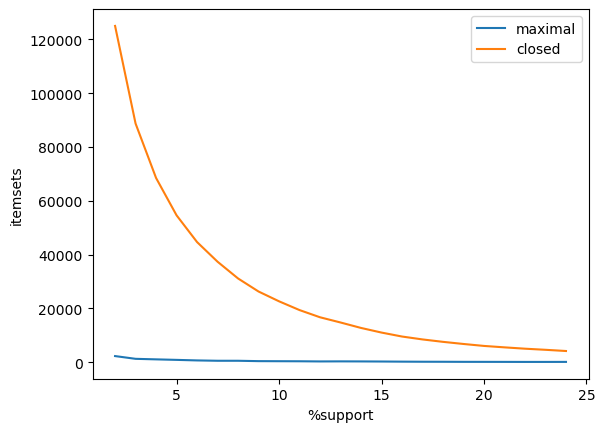

In [20]:
len_max_it = []
len_cl_it = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = apriori(X, target="m", supp=i, zmin=zmin)
    cl_itemsets = apriori(X, target="c", supp=i, zmin=zmin)
    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))

plt.plot(np.arange(2, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(2, max_supp), len_cl_it, label="closed")
plt.legend()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

#### Support vs number of itemset for low, medium and high rating

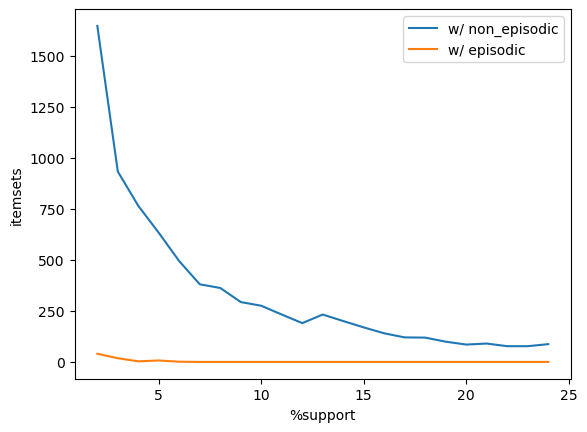

In [21]:
filter_1 = []
filter_2 = []

for i in range(2, max_supp):
    max_itemsets = apriori(X, target="m", supp=i, zmin=zmin)
    filter_1.append(len([item for item in max_itemsets if "non_episodic" in item[0]]))
    filter_2.append(len([item for item in max_itemsets if "episodic" in item[0]]))


plt.plot(np.arange(2, max_supp), filter_1, label="w/ non_episodic")
plt.plot(np.arange(2, max_supp), filter_2, label="w/ episodic")

plt.legend()
plt.xticks()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

### Rules

In [22]:
help(apriori)

Help on built-in function apriori in module fim:

apriori(...)
    apriori (tracts, target='s', supp=10, zmin=1, zmax=None, report='a',
             eval='x', agg='x', thresh=10, prune=None, algo='b', mode='',
             border=None)
    Find frequent item sets with the Apriori algorithm.
    tracts  transaction database to mine (mandatory)
            The database must be an iterable of transactions;
            each transaction must be an iterable of items;
            each item must be a hashable object.
            If the database is a dictionary, the transactions are
            the keys, the values their (integer) multiplicities.
    target  type of frequent item sets to find     (default: s)
            s/a   sets/all   all     frequent item sets
            c     closed     closed  frequent item sets
            m     maximal    maximal frequent item sets
            g     gens       generators
            r     rules      association rules
    supp    minimum support of an i

In [23]:
conf = 70
rules = apriori(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
# Drop rows where lift is less than 1
rules_df = rules_df[rules_df['lift'] >= 2]

# Optionally reset the index after filtering
rules_df.reset_index(drop=True, inplace=True)

rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
22,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
20,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
16,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
18,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
23,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
10780,movie,"(long_runtime, no_videos, low_votes, no_nominations, low_criticReviews, low_userReviews)",2492,21.521720,0.744547,2.000258
9099,movie,"(long_runtime, modern_cinema_era, no_videos, non_episodic, no_awards, low_criticReviews, low_userReviews)",1536,13.265394,0.744547,2.000257
9753,long_runtime,"(movie, small_scale_credits, very_low_images, no_nominations, non_episodic, not_adult)",1597,13.792210,0.784767,2.000179
9776,long_runtime,"(movie, small_scale_credits, very_low_images, no_nominations, not_adult)",1597,13.792210,0.784767,2.000179


In [24]:
rules_df['consequent'].unique()

array(['short', 'short_runtime', 'tvEpisode', 'movie', 'long_runtime'],
      dtype=object)

In [25]:
conf = 60
rules = apriori(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
# Drop rows where lift is less than 1
rules_df = rules_df[rules_df['lift'] >= 2]

# Optionally reset the index after filtering
rules_df.reset_index(drop=True, inplace=True)

rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
152,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
150,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
148,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
146,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
153,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
15638,movie,"(long_runtime, no_videos, low_votes, no_nominations, low_criticReviews, low_userReviews)",2492,21.521720,0.744547,2.000258
13957,movie,"(long_runtime, modern_cinema_era, no_videos, non_episodic, no_awards, low_criticReviews, low_userReviews)",1536,13.265394,0.744547,2.000257
14611,long_runtime,"(movie, small_scale_credits, very_low_images, no_nominations, non_episodic, not_adult)",1597,13.792210,0.784767,2.000179
14634,long_runtime,"(movie, small_scale_credits, very_low_images, no_nominations, not_adult)",1597,13.792210,0.784767,2.000179


In [26]:
rules_df['consequent'].unique()

array(['short', 'short_runtime', 'tvEpisode', 'movie', 'long_runtime'],
      dtype=object)

In [27]:
conf = 50
rules = apriori(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
# Drop rows where lift is less than 1
rules_df = rules_df[rules_df['lift'] >= 2]

# Optionally reset the index after filtering
rules_df.reset_index(drop=True, inplace=True)

rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
1040,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
1038,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
1034,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
1036,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
1041,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
22288,movie,"(long_runtime, no_videos, no_nominations, low_criticReviews, low_userReviews)",2552,22.039900,0.744457,2.000017
9375,regional,"(movie, medium_rating, very_low_images, no_videos, no_nominations)",770,6.649970,0.512309,2.000008
9364,regional,"(movie, medium_rating, very_low_images, no_videos, no_nominations, non_episodic)",770,6.649970,0.512309,2.000008
16058,tvEpisode,"(high_rating, modern_cinema_era, small_scale_credits, no_nominations, non_episodic, low_criticReviews, not_adult)",739,6.382244,0.557736,2.000007


In [28]:
rules_df['consequent'].unique()

array(['short', 'short_runtime', 'medium_runtime', 'tvEpisode',
       'regional', "['Other Countries']", 'movie', 'long_runtime'],
      dtype=object)

### Classification

In [29]:
rules_df['consequent'].unique()

array(['short', 'short_runtime', 'medium_runtime', 'tvEpisode',
       'regional', "['Other Countries']", 'movie', 'long_runtime'],
      dtype=object)

In [30]:
rules_df[rules_df["consequent"] == "long_runtime"].sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
7270,long_runtime,"(['Other Countries'], movie, low_votes, no_awards)",1101,9.508593,0.906173,2.309614
7266,long_runtime,"(['Other Countries'], movie, low_votes, no_awards, low_userReviews)",1101,9.508593,0.906173,2.309614
7238,long_runtime,"(['Other Countries'], movie, low_votes, non_episodic, no_awards)",1101,9.508593,0.906173,2.309614
7234,long_runtime,"(['Other Countries'], movie, low_votes, non_episodic, no_awards, low_userReviews)",1101,9.508593,0.906173,2.309614
7230,long_runtime,"(['Other Countries'], movie, low_votes, non_episodic, no_awards, low_criticReviews)",1100,9.499957,0.906096,2.309417
...,...,...,...,...,...,...
21019,long_runtime,"(movie, small_scale_credits, very_low_images, low_votes, no_nominations, non_episodic, low_criticReviews, not_adult)",1576,13.610847,0.784861,2.000418
21043,long_runtime,"(movie, small_scale_credits, very_low_images, low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",1576,13.610847,0.784861,2.000418
21047,long_runtime,"(movie, small_scale_credits, very_low_images, low_votes, no_nominations, low_criticReviews, not_adult)",1576,13.610847,0.784861,2.000418
21165,long_runtime,"(movie, small_scale_credits, very_low_images, no_nominations, not_adult)",1597,13.792210,0.784767,2.000179


In [31]:
rules_df[rules_df["consequent"] == "medium_runtime"].sort_values(by="confidence", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
5038,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_nominations, no_awards, low_userReviews)",654,5.648156,0.537387,2.761831
5037,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_nominations, no_awards, low_userReviews, not_adult)",654,5.648156,0.537387,2.761831
5021,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_nominations, non_episodic, no_awards, low_userReviews, not_adult)",654,5.648156,0.537387,2.761831
5022,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_nominations, non_episodic, no_awards, low_userReviews)",654,5.648156,0.537387,2.761831
5053,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, non_episodic, no_awards, low_userReviews, not_adult)",654,5.648156,0.537387,2.761831
...,...,...,...,...,...,...
5543,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, non_episodic, low_userReviews)",682,5.889973,0.500000,2.569685
5546,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, no_awards, low_criticReviews, low_userReviews, not_adult)",680,5.872701,0.500000,2.569685
5547,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, no_awards, low_criticReviews, not_adult)",682,5.889973,0.500000,2.569685
5553,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, low_userReviews)",682,5.889973,0.500000,2.569685


In [32]:
rules_df[rules_df["consequent"] == "short_runtime"].sort_values(by="confidence", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
3256,short_runtime,"(short, local, very_low_images, low_votes, non_episodic, no_awards, low_criticReviews, low_userReviews)",1166,10.069954,0.996581,2.767909
3274,short_runtime,"(short, local, very_low_images, low_votes, no_awards, low_criticReviews)",1166,10.069954,0.996581,2.767909
3324,short_runtime,"(short, local, very_low_images, no_awards, low_userReviews)",1166,10.069954,0.996581,2.767909
3322,short_runtime,"(short, local, very_low_images, no_awards, low_criticReviews)",1166,10.069954,0.996581,2.767909
3320,short_runtime,"(short, local, very_low_images, no_awards, low_criticReviews, low_userReviews)",1166,10.069954,0.996581,2.767909
...,...,...,...,...,...,...
4941,short_runtime,"(short, low_votes, no_nominations, not_adult)",1702,14.699024,0.990687,2.751538
4921,short_runtime,"(short, low_votes, no_nominations, non_episodic, low_criticReviews, not_adult)",1701,14.690388,0.990681,2.751523
4919,short_runtime,"(short, low_votes, no_nominations, non_episodic, low_criticReviews, low_userReviews, not_adult)",1701,14.690388,0.990681,2.751523
4935,short_runtime,"(short, low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",1701,14.690388,0.990681,2.751523


In [33]:
rules_df[rules_df["consequent"] == "very_long_runtime"].sort_values(by="confidence", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift


In [34]:
rules_df[rules_df["consequent"] == "tvEpisode"]

,consequent,antecedent,abs_support,%_support,confidence,lift
5326,tvEpisode,"(medium_runtime, high_rating, very_low_images, low_criticReviews, low_userReviews, not_adult)",811,7.004059,0.695540,2.494166
5327,tvEpisode,"(medium_runtime, high_rating, very_low_images, low_criticReviews, low_userReviews)",811,7.004059,0.692570,2.483516
5328,tvEpisode,"(medium_runtime, high_rating, very_low_images, low_criticReviews, not_adult)",811,7.004059,0.695540,2.494166
5329,tvEpisode,"(medium_runtime, high_rating, very_low_images, low_criticReviews)",811,7.004059,0.692570,2.483516
5330,tvEpisode,"(medium_runtime, high_rating, very_low_images, low_userReviews, not_adult)",811,7.004059,0.695540,2.494166
...,...,...,...,...,...,...
17341,tvEpisode,"(modern_cinema_era, local, no_awards, low_userReviews, not_adult)",1659,14.327662,0.572069,2.051405
17342,tvEpisode,"(modern_cinema_era, local, no_awards, not_adult)",1659,14.327662,0.572069,2.051405
17343,tvEpisode,"(modern_cinema_era, local, low_criticReviews, low_userReviews, not_adult)",1659,14.327662,0.562945,2.018688
17344,tvEpisode,"(modern_cinema_era, local, low_criticReviews, not_adult)",1659,14.327662,0.562945,2.018688


In [35]:
rules_df[rules_df["consequent"] == "movie"]

,consequent,antecedent,abs_support,%_support,confidence,lift
6955,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews, low_userReviews, not_adult)",992,8.567234,0.856649,2.301425
6956,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews, low_userReviews)",997,8.610415,0.855060,2.297155
6957,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews, not_adult)",992,8.567234,0.856649,2.301425
6958,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews)",997,8.610415,0.855060,2.297155
6959,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_userReviews, not_adult)",994,8.584506,0.856897,2.302089
...,...,...,...,...,...,...
22537,movie,"(long_runtime, no_awards, low_criticReviews, low_userReviews, not_adult)",2879,24.863978,0.783828,2.105787
22539,movie,"(long_runtime, no_awards, low_criticReviews, low_userReviews)",2945,25.433975,0.760000,2.041773
22541,movie,"(long_runtime, no_awards, low_criticReviews, not_adult)",2899,25.036704,0.783302,2.104374
22543,movie,"(long_runtime, no_awards, low_userReviews, not_adult)",2976,25.701701,0.788553,2.118482


In [36]:
rules_df[rules_df["consequent"] == "short"].sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
1038,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
1040,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
1034,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
1036,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
1039,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
553,short,"(short_runtime, contemporary_cinema_era, local, very_low_images, no_videos, low_votes, no_nominations, low_userReviews, not_adult)",614,5.302703,0.500000,3.059989
551,short,"(short_runtime, contemporary_cinema_era, local, very_low_images, no_videos, low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",614,5.302703,0.500000,3.059989
786,short,"(short_runtime, contemporary_cinema_era, local, no_videos, non_episodic, no_awards)",635,5.484066,0.500000,3.059989
856,short,"(short_runtime, contemporary_cinema_era, local, no_nominations, non_episodic, no_awards, not_adult)",659,5.691338,0.500000,3.059989


In [37]:
rules_df[rules_df["consequent"] == "regional"].sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
6609,regional,"(['Other Countries'], movie, long_runtime, low_votes, low_criticReviews, low_userReviews, not_adult)",650,5.613611,0.549915,2.146821
6601,regional,"(['Other Countries'], movie, long_runtime, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",650,5.613611,0.549915,2.146821
6611,regional,"(['Other Countries'], movie, long_runtime, low_votes, low_criticReviews, not_adult)",650,5.613611,0.549915,2.146821
6603,regional,"(['Other Countries'], movie, long_runtime, low_votes, non_episodic, low_criticReviews, not_adult)",650,5.613611,0.549915,2.146821
6612,regional,"(['Other Countries'], movie, long_runtime, low_votes, low_criticReviews)",652,5.630883,0.549284,2.144355
...,...,...,...,...,...,...
8046,regional,"(movie, long_runtime, small_scale_credits, very_low_images, no_videos, low_votes, non_episodic, no_awards, low_criticReviews, low_userReviews, not_adult)",748,6.459971,0.512329,2.000086
7777,regional,"(movie, long_runtime, medium_rating, very_low_images, no_nominations, non_episodic, not_adult)",686,5.924519,0.512323,2.000062
7781,regional,"(movie, long_runtime, medium_rating, very_low_images, no_nominations, not_adult)",686,5.924519,0.512323,2.000062
9364,regional,"(movie, medium_rating, very_low_images, no_videos, no_nominations, non_episodic)",770,6.649970,0.512309,2.000008


In [38]:
# len_r = []
# min_sup = 1
# max_sup = 20
# min_conf = 50
# max_conf = 90
# for i in range(min_sup, max_sup):  # support
#     len_r_wrt_i = []
#     for j in range(min_conf, max_conf):  # confidence
#         rules = apriori(X, target="r", supp=i, zmin=zmin, conf=j, report="aScl")
#         len_r_wrt_i.append(len(rules))  # study your characteristics/properties here

#     len_r.append(len_r_wrt_i)
# len_r = np.array(len_r)

In [39]:
# sns.heatmap(len_r, cmap="Blues", fmt='g')
# plt.yticks(np.arange(0, max_sup-min_sup +1, 5), np.arange(min_sup, max_sup+1,5 ))
# plt.xticks(np.arange(0, max_conf-min_conf+1, 5), np.arange(min_conf, max_conf+1, 5))
# plt.xlabel("%confidence")
# plt.ylabel("%support")
# plt.show()

## FP-Growth

In [40]:
from fim import fpgrowth

In [41]:
help(fpgrowth)

Help on built-in function fpgrowth in module fim:

fpgrowth(...)
    fpgrowth (tracts, target='s', supp=10, zmin=1, zmax=None, report='a',
              eval='x', agg='x', thresh=10, prune=Nobe, algo='s', mode='',
              border=None)
    Find frequent item sets with the FP-growth algorithm.
    tracts  transaction database to mine (mandatory)
            The database must be an iterable of transactions;
            each transaction must be an iterable of items;
            each item must be a hashable object.
            If the database is a dictionary, the transactions are
            the keys, the values their (integer) multiplicities.
    target  type of frequent item sets to find     (default: s)
            s/a   sets/all   all     frequent item sets
            c     closed     closed  frequent item sets
            m     maximal    maximal frequent item sets
            g     gens       generators
            r     rules      association rules
    supp    minimum support 

In [42]:

supp = 10  # 20%
zmin = 5  # minimum number of items per item set

itemsets = fpgrowth(X, target="s", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"]).sort_values(by="support", axis=0, ascending=True)

,frequent_itemset,support
45979,"(regional, medium_rating, small_scale_credits, low_votes, no_awards, low_userReviews, low_criticReviews)",10.000864
52730,"(short, short_runtime, local, small_scale_credits, no_awards, non_episodic, low_userReviews, low_criticReviews)",10.000864
52729,"(short, short_runtime, local, small_scale_credits, no_awards, non_episodic, low_userReviews, low_votes)",10.000864
52728,"(short, short_runtime, local, small_scale_credits, no_awards, non_episodic, low_userReviews, low_votes, low_criticReviews)",10.000864
47226,"(regional, movie, long_runtime, very_low_images, low_votes, no_awards, non_episodic, low_userReviews)",10.000864
...,...,...
51,"(no_videos, low_votes, low_criticReviews, low_userReviews, not_adult)",82.468262
13,"(low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",83.634165
17,"(low_votes, no_nominations, no_awards, low_criticReviews, low_userReviews)",83.755074
7,"(low_votes, no_awards, low_criticReviews, low_userReviews, not_adult)",83.996891


In [43]:
conf = 70
rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
# Drop rows where lift is less than 1
# rules_df = rules_df[rules_df['lift'] >= 2]

# # Optionally reset the index after filtering
# rules_df.reset_index(drop=True, inplace=True)
rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
311564,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
311563,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
311567,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
311566,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
311570,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
208496,low_votes,"(medium_scale_credits, movie, non_episodic, not_adult)",1167,10.078591,0.722601,0.791654
208559,no_videos,"(medium_scale_credits, movie, no_nominations, non_episodic, no_awards)",822,7.099059,0.703165,0.788643
208555,no_videos,"(medium_scale_credits, movie, no_nominations, no_awards)",822,7.099059,0.703165,0.788643
208558,no_videos,"(medium_scale_credits, movie, no_nominations, non_episodic, no_awards, not_adult)",819,7.073150,0.702401,0.787786


In [44]:
rules_df['consequent'].unique()

array(['not_adult', 'low_userReviews', 'low_criticReviews', 'no_awards',
       'non_episodic', 'no_nominations', 'low_votes', 'no_videos',
       'very_low_images', 'small_scale_credits', 'local', 'long_runtime',
       'movie', 'high_rating', 'modern_cinema_era', 'tvEpisode',
       'short_runtime', 'short'], dtype=object)

In [45]:
conf = 60
rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
# # Drop rows where lift is less than 1
# rules_df = rules_df[rules_df['lift'] >= 2]

# # Optionally reset the index after filtering
rules_df.reset_index(drop=True, inplace=True)
rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
356173,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
356172,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
356176,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
356175,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
356179,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
227915,no_videos,"(medium_scale_credits, movie, non_episodic, not_adult)",1040,8.981777,0.643963,0.722244
157990,no_videos,"(movie, long_runtime, contemporary_cinema_era, non_episodic)",787,6.796787,0.638799,0.716452
157989,no_videos,"(movie, long_runtime, contemporary_cinema_era, non_episodic, not_adult)",786,6.788151,0.638505,0.716123
157988,no_videos,"(movie, long_runtime, contemporary_cinema_era, not_adult)",786,6.788151,0.638505,0.716123


In [46]:
rules_df['consequent'].unique()

array(['not_adult', 'low_userReviews', 'low_criticReviews', 'no_awards',
       'non_episodic', 'no_nominations', 'low_votes', 'no_videos',
       'very_low_images', 'small_scale_credits', 'local', 'high_rating',
       "['US']", 'modern_cinema_era', 'medium_rating', 'long_runtime',
       'movie', 'short_runtime', 'tvEpisode', 'medium_scale_credits',
       'short'], dtype=object)

In [47]:
conf = 50
rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
# Drop rows where lift is less than 1
rules_df = rules_df[rules_df['lift'] >= 2]

# Optionally reset the index after filtering
rules_df.reset_index(drop=True, inplace=True)
rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
21503,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
21504,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
21506,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
21507,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
21505,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
259,movie,"(long_runtime, no_videos, no_nominations, low_criticReviews, low_userReviews)",2552,22.039900,0.744457,2.000017
13190,regional,"(movie, medium_rating, very_low_images, no_videos, no_nominations, non_episodic)",770,6.649970,0.512309,2.000008
13191,regional,"(movie, medium_rating, very_low_images, no_videos, no_nominations)",770,6.649970,0.512309,2.000008
6487,tvEpisode,"(high_rating, modern_cinema_era, small_scale_credits, no_nominations, non_episodic, low_criticReviews, not_adult)",739,6.382244,0.557736,2.000007


In [48]:
rules_df['consequent'].unique()

array(['long_runtime', 'movie', 'tvEpisode', 'regional',
       "['Other Countries']", 'medium_runtime', 'short_runtime', 'short'],
      dtype=object)

In [49]:
rules_df[rules_df["consequent"] == "long_runtime"].sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
15318,long_runtime,"(['Other Countries'], movie, low_votes, non_episodic, no_awards)",1101,9.508593,0.906173,2.309614
15278,long_runtime,"(['Other Countries'], movie, low_votes, no_awards, low_userReviews)",1101,9.508593,0.906173,2.309614
15308,long_runtime,"(['Other Countries'], movie, low_votes, non_episodic, no_awards, low_userReviews)",1101,9.508593,0.906173,2.309614
15288,long_runtime,"(['Other Countries'], movie, low_votes, no_awards)",1101,9.508593,0.906173,2.309614
15286,long_runtime,"(['Other Countries'], movie, low_votes, no_awards, low_criticReviews)",1100,9.499957,0.906096,2.309417
...,...,...,...,...,...,...
1517,long_runtime,"(movie, small_scale_credits, very_low_images, low_votes, no_nominations, non_episodic, low_criticReviews, not_adult)",1576,13.610847,0.784861,2.000418
1493,long_runtime,"(movie, small_scale_credits, very_low_images, low_votes, no_nominations, low_criticReviews, low_userReviews, not_adult)",1576,13.610847,0.784861,2.000418
1519,long_runtime,"(movie, small_scale_credits, very_low_images, low_votes, no_nominations, non_episodic, low_criticReviews, low_userReviews, not_adult)",1576,13.610847,0.784861,2.000418
1398,long_runtime,"(movie, small_scale_credits, very_low_images, no_nominations, non_episodic, not_adult)",1597,13.792210,0.784767,2.000179


In [50]:
rules_df[rules_df["consequent"] == "medium_runtime"].sort_values(by="confidence", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
17489,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, non_episodic, no_awards, low_userReviews, not_adult)",654,5.648156,0.537387,2.761831
17474,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_awards, low_userReviews, not_adult)",654,5.648156,0.537387,2.761831
17505,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_nominations, no_awards, low_userReviews, not_adult)",654,5.648156,0.537387,2.761831
17506,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_nominations, no_awards, low_userReviews)",654,5.648156,0.537387,2.761831
17475,medium_runtime,"(tvEpisode, medium_scale_credits, high_rating, no_awards, low_userReviews)",654,5.648156,0.537387,2.761831
...,...,...,...,...,...,...
16997,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, no_awards, low_criticReviews, not_adult)",682,5.889973,0.500000,2.569685
16998,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, no_awards, low_criticReviews, low_userReviews, not_adult)",680,5.872701,0.500000,2.569685
17025,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, no_nominations, non_episodic, no_awards, low_criticReviews, not_adult)",682,5.889973,0.500000,2.569685
17016,medium_runtime,"(tvEpisode, contemporary_cinema_era, no_videos, no_nominations, no_awards, low_criticReviews, not_adult)",682,5.889973,0.500000,2.569685


In [51]:
rules_df[rules_df["consequent"] == "short_runtime"]

,consequent,antecedent,abs_support,%_support,confidence,lift
17529,short_runtime,"(short, low_criticReviews, low_userReviews, not_adult)",1872,16.167199,0.991525,2.753867
17530,short_runtime,"(short, no_awards, low_userReviews, not_adult)",1724,14.889023,0.991945,2.755032
17531,short_runtime,"(short, no_awards, low_criticReviews, not_adult)",1724,14.889023,0.991945,2.755032
17532,short_runtime,"(short, no_awards, low_criticReviews, low_userReviews, not_adult)",1724,14.889023,0.991945,2.755032
17533,short_runtime,"(short, no_awards, low_criticReviews, low_userReviews)",1727,14.914932,0.991959,2.755071
...,...,...,...,...,...,...
19767,short_runtime,"(short, local, small_scale_credits, very_low_images, low_votes, non_episodic, low_criticReviews, low_userReviews)",1192,10.294499,0.995823,2.765803
19769,short_runtime,"(short, local, small_scale_credits, very_low_images, low_votes, non_episodic, low_criticReviews)",1192,10.294499,0.995823,2.765803
19779,short_runtime,"(short, local, small_scale_credits, very_low_images, low_votes, non_episodic)",1192,10.294499,0.995823,2.765803
19813,short_runtime,"(short, local, small_scale_credits, very_low_images, low_votes)",1192,10.294499,0.995823,2.765803


In [52]:
rules_df[rules_df["consequent"] == "tvEpisode"].sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
12710,tvEpisode,"(medium_scale_credits, high_rating, local, no_videos, no_nominations, non_episodic, no_awards)",1067,9.214958,0.921416,3.304143
12647,tvEpisode,"(medium_scale_credits, high_rating, local, no_nominations, non_episodic, no_awards, not_adult)",1137,9.819501,0.917676,3.290729
12650,tvEpisode,"(medium_scale_credits, high_rating, local, no_nominations, non_episodic, no_awards, low_criticReviews, not_adult)",1133,9.784956,0.917409,3.289773
12648,tvEpisode,"(medium_scale_credits, high_rating, local, no_nominations, non_episodic, no_awards, low_userReviews, not_adult)",1132,9.776319,0.917342,3.289533
12651,tvEpisode,"(medium_scale_credits, high_rating, local, no_nominations, non_episodic, no_awards, low_criticReviews, low_userReviews, not_adult)",1130,9.759047,0.917208,3.289052
...,...,...,...,...,...,...
7334,tvEpisode,"(['US'], local, very_low_images, low_votes, no_awards, low_criticReviews, not_adult)",1453,12.548579,0.557774,2.000142
7333,tvEpisode,"(['US'], local, very_low_images, low_votes, no_awards, low_userReviews, not_adult)",1453,12.548579,0.557774,2.000142
7332,tvEpisode,"(['US'], local, very_low_images, low_votes, no_awards, not_adult)",1453,12.548579,0.557774,2.000142
6488,tvEpisode,"(high_rating, modern_cinema_era, small_scale_credits, no_nominations, non_episodic, low_criticReviews, low_userReviews, not_adult)",739,6.382244,0.557736,2.000007


In [53]:
rules_df[rules_df["consequent"] == "movie"]

,consequent,antecedent,abs_support,%_support,confidence,lift
1,movie,"(long_runtime, low_criticReviews, low_userReviews, not_adult)",3173,27.403057,0.793845,2.132700
3,movie,"(long_runtime, no_awards, low_userReviews, not_adult)",2976,25.701701,0.788553,2.118482
5,movie,"(long_runtime, no_awards, low_criticReviews, not_adult)",2899,25.036704,0.783302,2.104374
7,movie,"(long_runtime, no_awards, low_criticReviews, low_userReviews, not_adult)",2879,24.863978,0.783828,2.105787
9,movie,"(long_runtime, no_awards, low_criticReviews, low_userReviews)",2945,25.433975,0.760000,2.041773
...,...,...,...,...,...,...
15586,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews, not_adult)",992,8.567234,0.856649,2.301425
15587,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews, low_userReviews, not_adult)",992,8.567234,0.856649,2.301425
15588,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews, low_userReviews)",997,8.610415,0.855060,2.297155
15589,movie,"(['Other Countries'], long_runtime, very_low_images, low_votes, low_criticReviews)",997,8.610415,0.855060,2.297155


In [54]:
rules_df[rules_df["consequent"] == "short"].sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
21503,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, not_adult)",881,7.608602,0.712207,4.358691
21504,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_userReviews, not_adult)",881,7.608602,0.712207,4.358691
21506,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, not_adult)",880,7.599965,0.711974,4.357267
21507,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic, low_criticReviews, low_userReviews, not_adult)",880,7.599965,0.711974,4.357267
21510,short,"(short_runtime, contemporary_cinema_era, small_scale_credits, low_votes, non_episodic)",881,7.608602,0.711057,4.351656
...,...,...,...,...,...,...
21989,short,"(short_runtime, contemporary_cinema_era, local, very_low_images, no_videos, low_votes, no_nominations, low_userReviews, not_adult)",614,5.302703,0.500000,3.059989
21988,short,"(short_runtime, contemporary_cinema_era, local, very_low_images, no_videos, low_votes, no_nominations, not_adult)",614,5.302703,0.500000,3.059989
21765,short,"(short_runtime, contemporary_cinema_era, local, no_videos, non_episodic, no_awards)",635,5.484066,0.500000,3.059989
21688,short,"(short_runtime, contemporary_cinema_era, local, no_nominations, non_episodic, no_awards, not_adult)",659,5.691338,0.500000,3.059989
